## **0. Settings**

In [1]:
import os, sys
sys.path.append(os.path.abspath('..'))

## **1. Import Libraries**

In [31]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from src.training import data_loader, model
from src.evaluation import inference

## **2. Load Model**

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
# Load best checkpoint
model =  model.AIContentModel(model_name='Qualcomm-AI-Research/BamiBERT', num_classes=2)
checkpoint = torch.load('../models/best_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: Qualcomm-AI-Research/BamiBERT
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.decoder.bias      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


AIContentModel(
  (bert): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(20481, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(2050, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerN

## **3. Load Data**

In [5]:
test_df = pd.read_csv('../data/subsets/test_df.csv')
test_dataset = torch.load('../data/encoded/test_dataset.pt', map_location=device, weights_only=False)
test_loader = data_loader.create_dataloader(test_dataset, batch_size=4, shuffle=False)

## **4. Run Inference**

In [6]:
all_preds, all_labels, all_probs = inference.predict(model, test_loader, device)
test_df['prediction'] = all_preds
test_df['prob_ai'] = all_probs

## **5. Overall Metrics**

In [7]:
report = classification_report(all_preds, all_labels)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.88      0.93       429
           1       0.87      0.99      0.93       337

    accuracy                           0.93       766
   macro avg       0.93      0.94      0.93       766
weighted avg       0.94      0.93      0.93       766



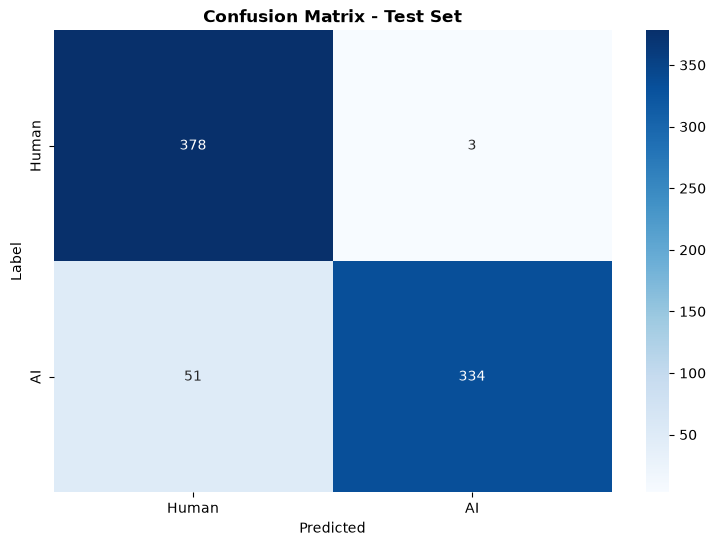

In [14]:
plt.figure(figsize=(9, 6))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
plt.title('Confusion Matrix - Test Set', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Label')
plt.savefig('../figures/evaluation/confusion_matrix_test_set.png')
plt.show()

In [16]:
# Accuracy by Generated Types
gen_types = ['human', 'rewrited', 'generated']
results_by_type = {}
for gen_type in gen_types:
    mask = (test_df['generated_type'] == gen_type)
    if mask.sum() == 0:
        continue
    subset_acc = (test_df.loc[mask, 'prediction'] == test_df.loc[mask, 'label']).mean()
    results_by_type[gen_type] = subset_acc
    print(f'{gen_type}: {subset_acc:.2%} ({mask.sum()} samples)')

human: 99.21% (381 samples)
rewrited: 76.35% (203 samples)
generated: 98.35% (182 samples)


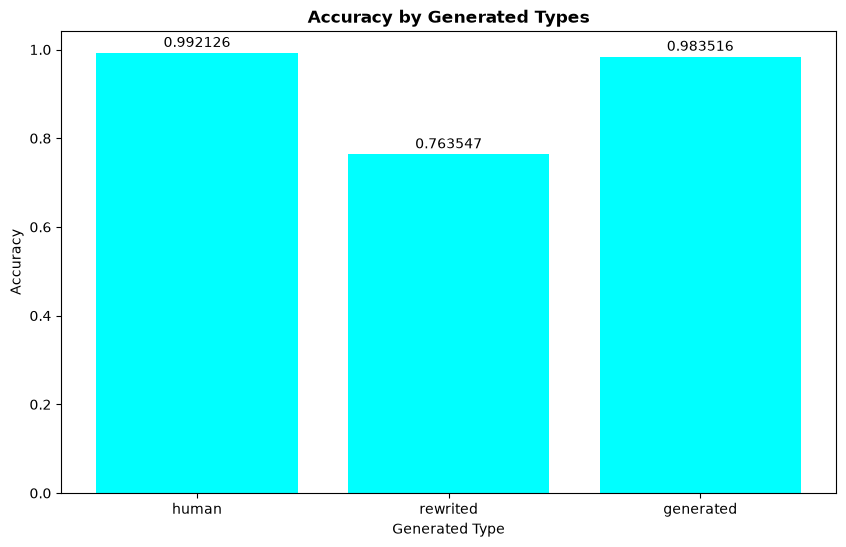

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(results_by_type.keys(), results_by_type.values(), color='aqua')
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=2)

plt.title('Accuracy by Generated Types', fontweight='bold')
plt.xlabel('Generated Type')
plt.ylabel('Accuracy')
plt.savefig('../figures/evaluation/accuracy_by_generated_types.png')
plt.show()

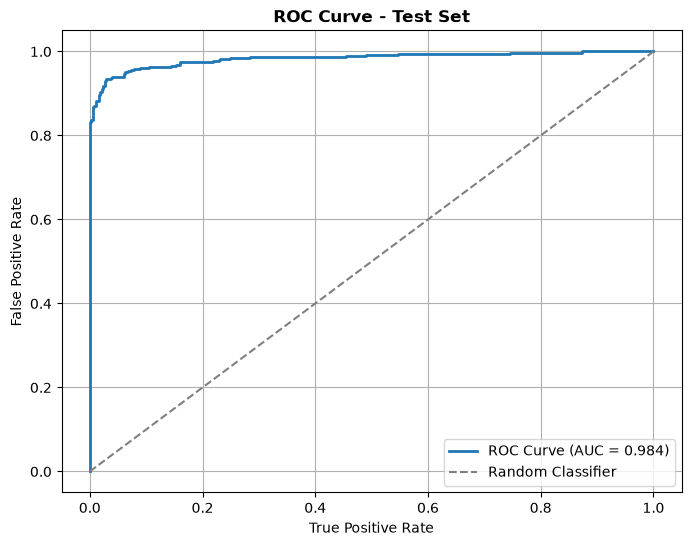

In [39]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
auc_score = roc_auc_score(all_labels, all_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.title('ROC Curve - Test Set', fontweight='bold')
plt.xlabel('True Positive Rate')
plt.ylabel('False Positive Rate')
plt.grid(True)
plt.legend()
plt.savefig('../figures/evaluation/roc_curve.png')
plt.show()

## **6. Save Dataframe**

In [40]:
test_df.to_csv('../data/evaluated/test_df_evaluated.csv', index=False, encoding='utf-8-sig')